## How Faithfull is your Synthetic Data?
#### Sample- level Metrics for Evaluating and Auditing GEnerative Models

Authors:
- Ahmed M. Alaa
- Boris van Breugel
- Evgeny Saveliev
- Mihaela van der Schaar

The paper introduces a 3-dimensional metric:


1.   $\alpha$ -precision
2.   $\beta$-Recall
3.



In [ ]:
from tensorflow import keras

[Kaggle Cancer Dataset](https://www.kaggle.com/datasets/erdemtaha/cancer-data)

In [ ]:
### DATA
import kagglehub

# Download latest version
path = kagglehub.dataset_download("erdemtaha/cancer-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cancer-data' dataset.
Path to dataset files: /kaggle/input/cancer-data


In [ ]:
import os
import pandas as pd
files_in_directory = os.listdir(path)

# Filter for CSV files
csv_files = [f for f in files_in_directory if f.endswith('.csv')]

if csv_files:
    # Assuming the first CSV file found is the one intended.
    # If there are multiple, you might need to specify the correct one.
    csv_file_name = csv_files[0]
    full_csv_path = os.path.join(path, csv_file_name)
    print(f"Reading CSV file: {full_csv_path}")
    cancer_df = pd.read_csv(full_csv_path)
else:
    print(f"Error: No CSV files found in the directory: {path}")
    cancer_df = None # Set to None or handle as appropriate if no CSV is found

Reading CSV file: /kaggle/input/cancer-data/Cancer_Data.csv


In [ ]:
cancer_df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [ ]:
mapping = {'B': 0, 'M':1} # Categories not in the map remain as they are unless specified otherwise

# Apply the mapping to a new column
cancer_df['diagnosis'] = cancer_df['diagnosis'].replace(mapping)

In [ ]:
X = cancer_df.drop(columns=['id','diagnosis', "Unnamed: 32"])
y = cancer_df['diagnosis']


In [ ]:
y

,diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


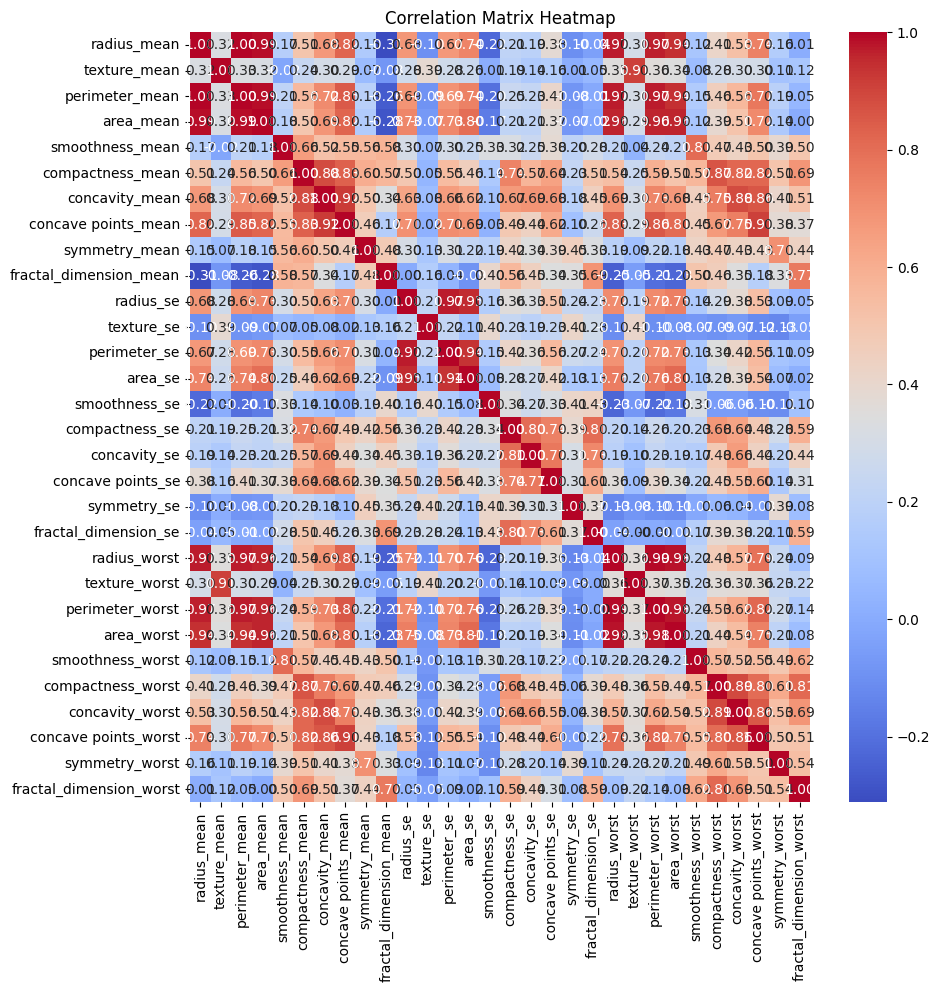

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
sns.heatmap(X_correlations, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

cancer_scaler = StandardScaler()
X = cancer_scaler.fit_transform(X)

## Feature Selection

In [ ]:
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel

lsvc = LinearSVC(C=0.01, penalty="l1", dual=False).fit(X, y)
model = SelectFromModel(lsvc, prefit=True)
X_new = model.transform(X)
X_new = pd.DataFrame(X_new)


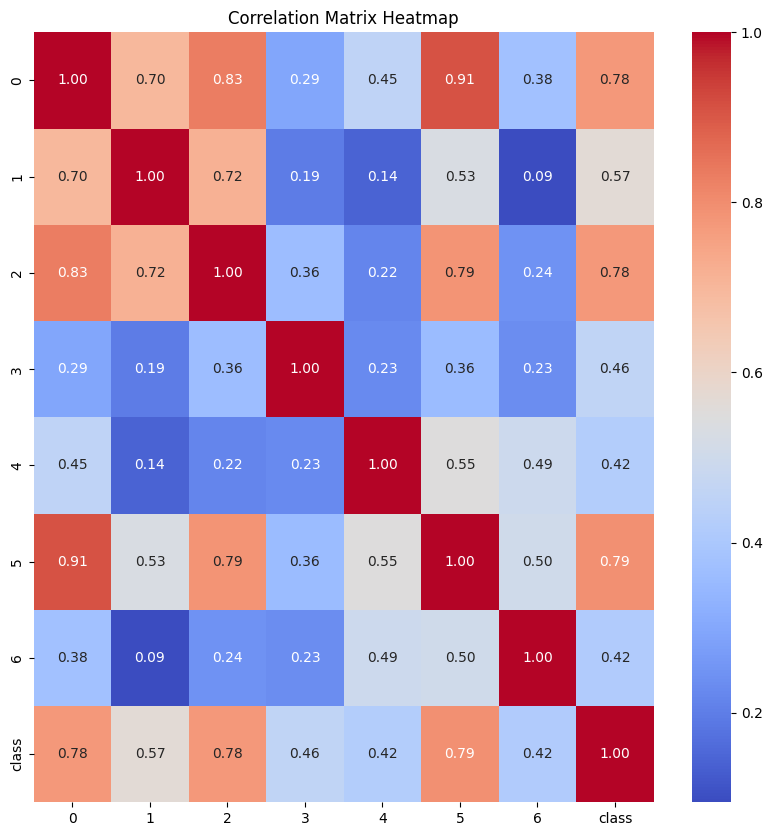

In [ ]:
plt.figure(figsize=(10, 10))
sns.heatmap(X_new.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
        <Axes: title={'center': '2'}>],
       [<Axes: title={'center': '3'}>, <Axes: title={'center': '4'}>,
        <Axes: title={'center': '5'}>],
       [<Axes: title={'center': '6'}>, <Axes: >, <Axes: >]], dtype=object)

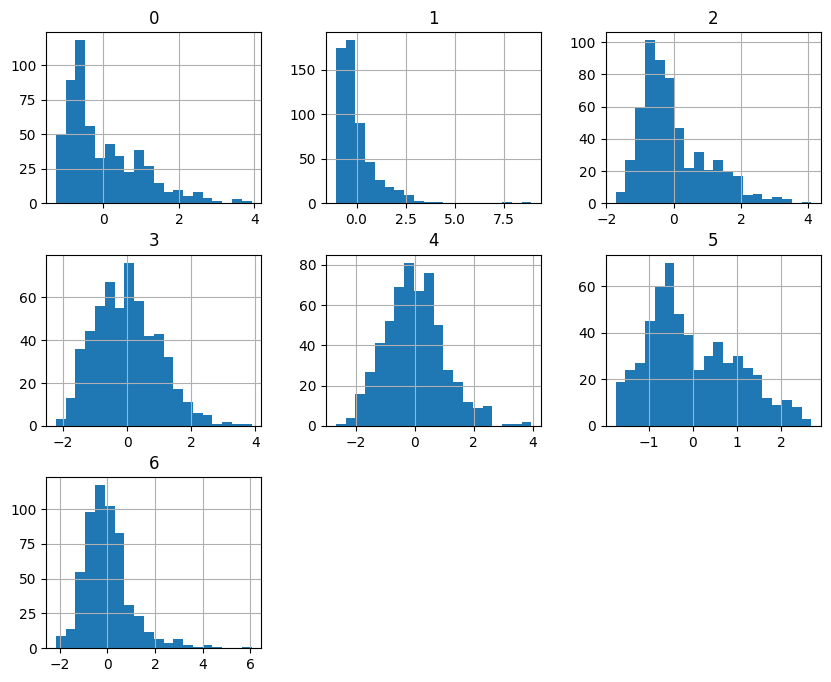

In [ ]:
X_new.hist(bins=20, figsize=(10, 8))

In [ ]:
Zs_train = X_new.copy()


In [ ]:
Zs.shape # (569, 7)

(569, 7)

In [ ]:
num_features = Zs_train.shape[1]
latent_dim = max(32, 4 * num_features)

In [ ]:
from tensorflow.keras import layers

discriminator = keras.Sequential([
    keras.Input(shape=(num_features,)),
    layers.Dense(256), layers.LeakyReLU(0.2),
    layers.Dropout(0.2),
    layers.Dense(256), layers.LeakyReLU(0.2),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
], name="discriminator")

In [ ]:
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 256)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_49 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_50 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,097 (266.00 KB)

 Trainable params: 68,097 (266.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
generator = keras.Sequential([
    keras.Input(shape=(latent_dim,)),
    layers.Dense(128), layers.LeakyReLU(0.2),
    layers.Dense(256), layers.LeakyReLU(0.2),
    layers.Dense(512), layers.LeakyReLU(0.2),
    layers.Dense(num_features)  # <-- no sigmoid
], name="generator")

In [ ]:
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_51 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_52 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_53 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,423 (673.53 KB)

 Trainable params: 172,423 (673.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
class GAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(GAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim))
        generated_images = self.generator(random_latent_vectors)
        combined_images = tf.concat([generated_images, real_images], axis=0)
        labels = tf.concat(
            [tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))],
            axis=0
        )
        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim))

        misleading_labels = tf.zeros((batch_size, 1))

        with tf.GradientTape() as tape:
            predictions = self.discriminator(
                self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(
            zip(grads, self.generator.trainable_weights))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        return {"d_loss": self.d_loss_metric.result(),
                "g_loss": self.g_loss_metric.result()}

In [ ]:
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_samples=5, latent_dim=128):
        self.num_samples = num_samples
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.normal(shape=(self.num_samples, self.latent_dim))
        generated_data = self.model.generator(random_latent_vectors)
        print(f"\n--- Generated samples at epoch {epoch+1:03d} ---")
        # Use numpy() to convert to a NumPy array for easier printing
        print(generated_data.numpy())
        print("-------------------------------------------")


In [ ]:
gan = GAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(1e-4),
    g_optimizer=keras.optimizers.Adam(1e-4),
    loss_fn=keras.losses.BinaryCrossentropy(from_logits=False),
)

gan.fit(Zs_train, epochs=500, callbacks=[GANMonitor(num_samples=5, latent_dim=latent_dim)])

Streaming output truncated to the last 5000 lines.
  -1.9688252 ]
 [-2.3358116  -2.1611702  -0.9216588   2.405228    1.8384386  -0.6447507
  -2.2845335 ]]
-------------------------------------------
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.7409 - g_loss: 0.9970
Epoch 168/500
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - d_loss: 0.6972 - g_loss: 1.1051
--- Generated samples at epoch 168 ---
[[-1.0772142  -1.9343666  -0.8303095   0.38313514  1.2126818  -0.30386642
  -0.9016961 ]
 [-1.2608606  -2.2999756  -0.95049286  0.5762035   1.5911845  -0.38321674
  -1.1420214 ]
 [-1.2567792  -2.7378297  -1.4091398   0.47726995  1.6242137  -0.51761216
  -0.94055384]
 [-1.8010062  -3.1296585  -1.5245805   1.0624202   2.2057412  -0.34968224
  -1.4787813 ]
 [-0.98516804 -1.8993918  -0.9769685   0.47371334  1.3075929  -0.10863984
  -0.7675898 ]]
-------------------------------------------
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - d_loss: 0.6966 - g_loss: 1.1052
Epoch 169/500
15/18 ━━━━━━━━━━━━━━━━

In [ ]:

num_new_samples = 569

# Generate random latent vectors as input to the generator
random_latent_vectors = tf.random.normal(shape=(num_new_samples, latent_dim))

# Use the trained generator to create new samples
generated_samples = gan.generator(random_latent_vectors)

# Print the generated samples
print("--- Newly Generated Synthetic Tabular Data Samples ---")
print(generated_samples.numpy())
print("--------------------------------------------------")

--- Newly Generated Synthetic Tabular Data Samples ---
[[-1.6021209  -1.0307534  -0.20308025 ... -0.5230161  -0.8133313
  -0.40198955]
 [ 0.6548102  -0.25245982  1.1519167  ...  0.6513204   1.1148491
   0.41867194]
 [ 0.0053429  -0.55985695  0.41256243 ...  0.09135779  0.41012397
  -0.31849205]
 ...
 [ 4.084081    0.47036657  3.047155   ...  2.0043921   4.056187
   2.1442096 ]
 [-0.87767243 -0.7605933   0.06607521 ... -0.33598214 -0.35579142
  -0.13914125]
 [ 0.35570586 -0.62294024  0.9498349  ...  0.3388716   0.88764334
  -0.12522839]]
--------------------------------------------------


array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
        <Axes: title={'center': '2'}>],
       [<Axes: title={'center': '3'}>, <Axes: title={'center': '4'}>,
        <Axes: title={'center': '5'}>],
       [<Axes: title={'center': '6'}>, <Axes: >, <Axes: >]], dtype=object)

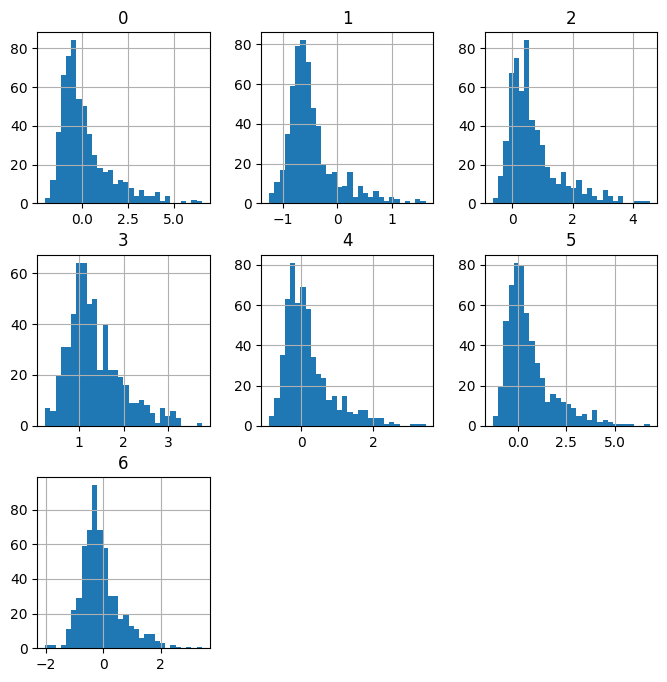

In [ ]:
generated_samples = pd.DataFrame(generated_samples)
generated_samples.hist(bins=30, figsize=(8, 8))

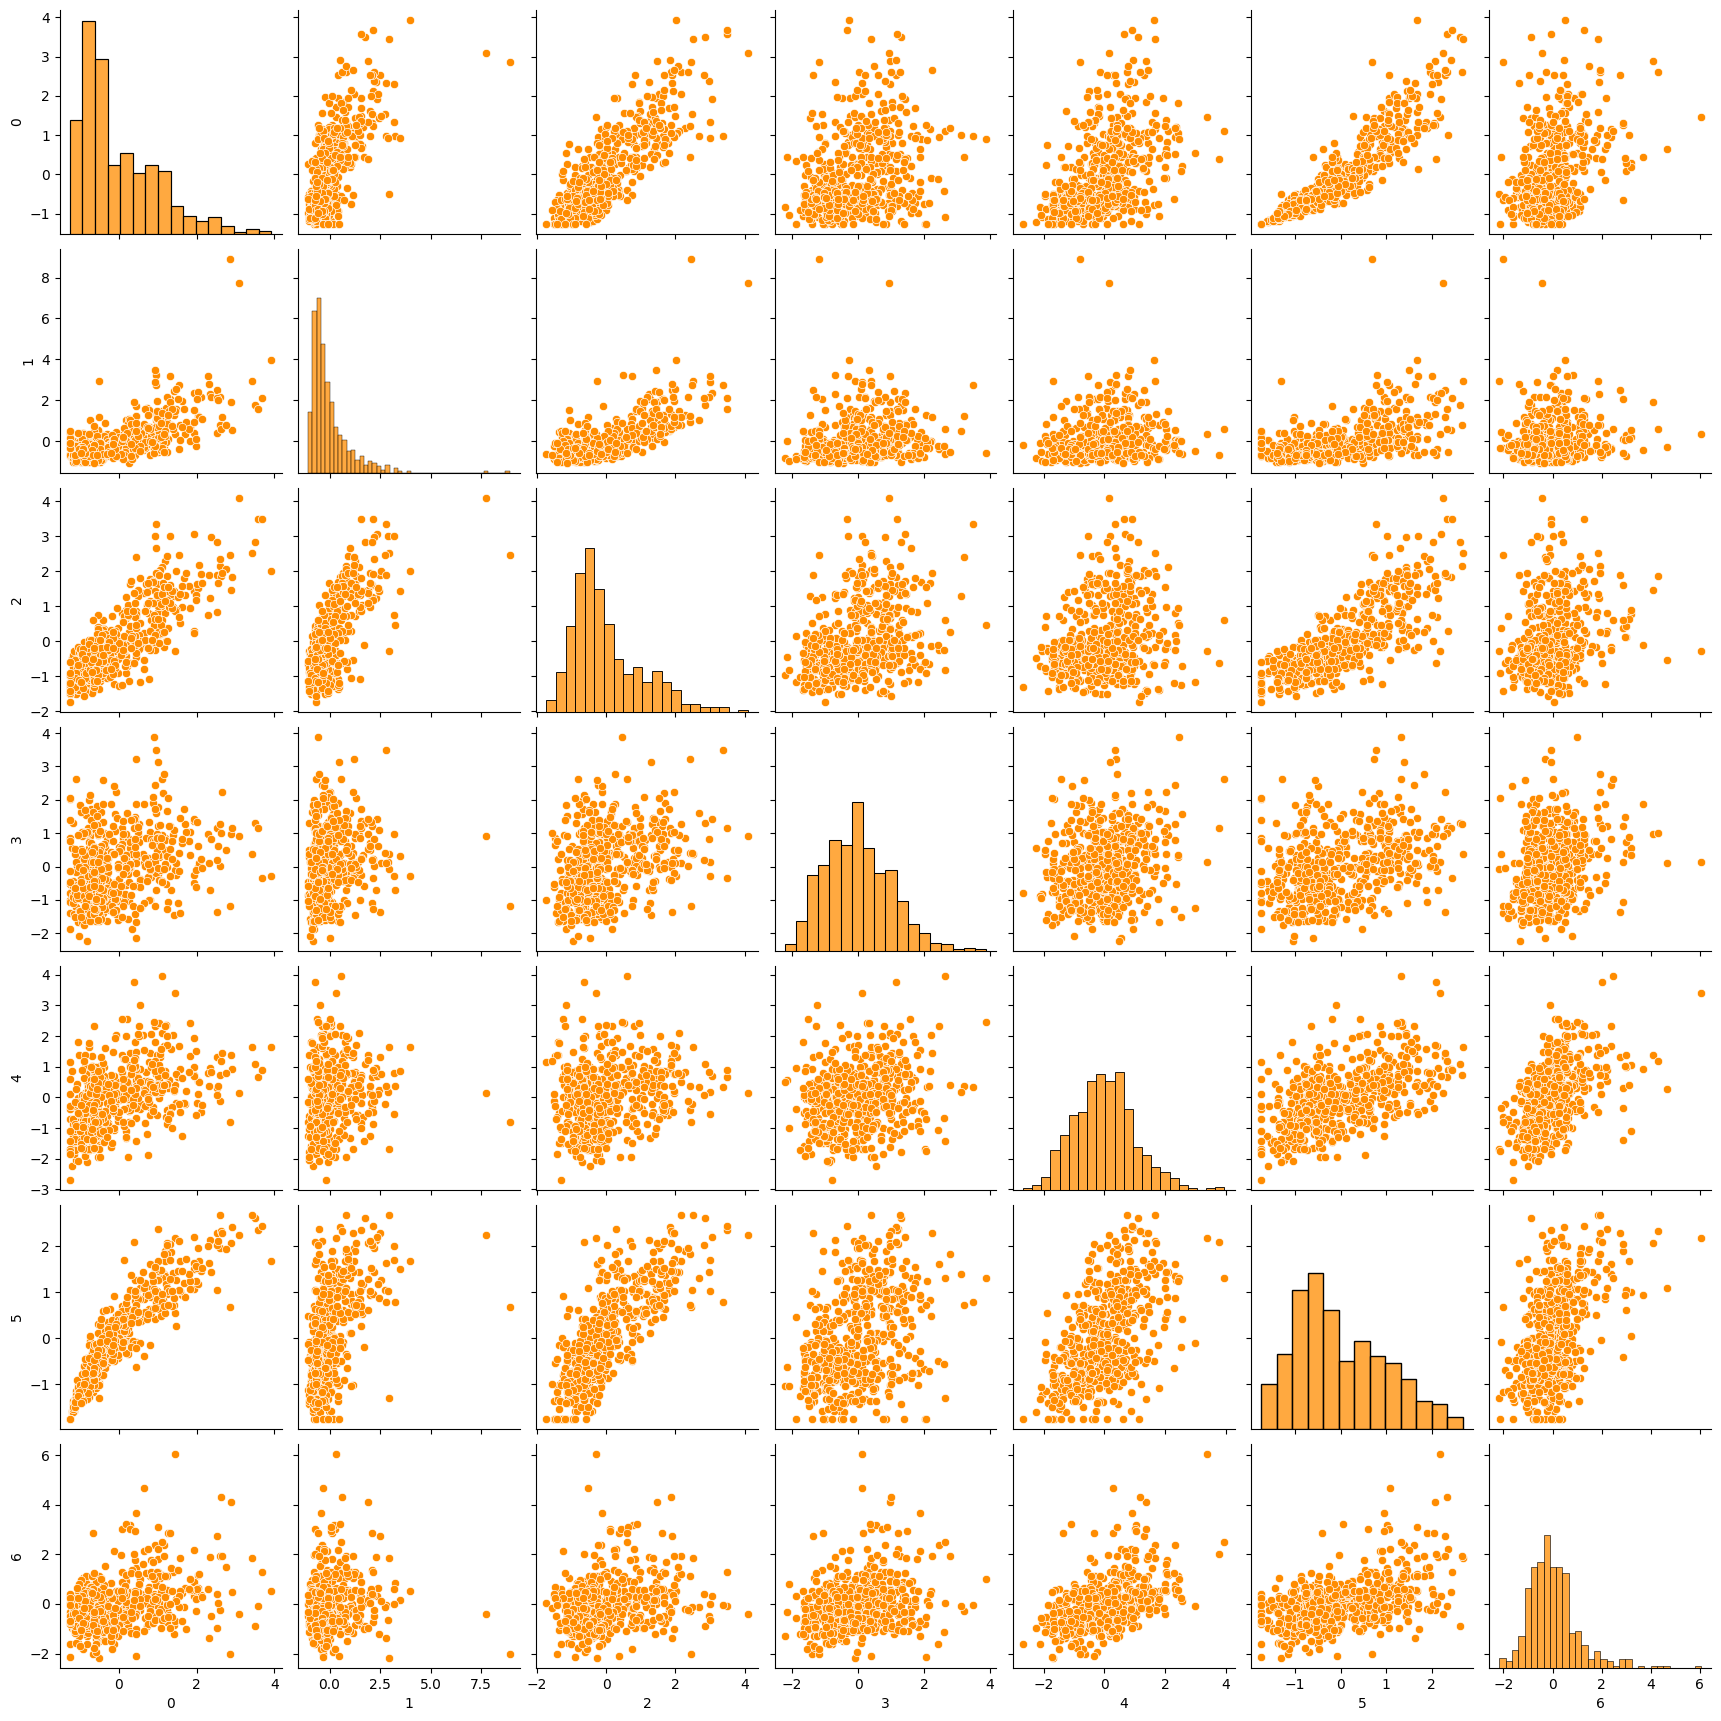

In [ ]:
sns.pairplot(Zs_train,     diag_kws={'color': 'darkorange'},
    plot_kws={'color': 'darkorange'})

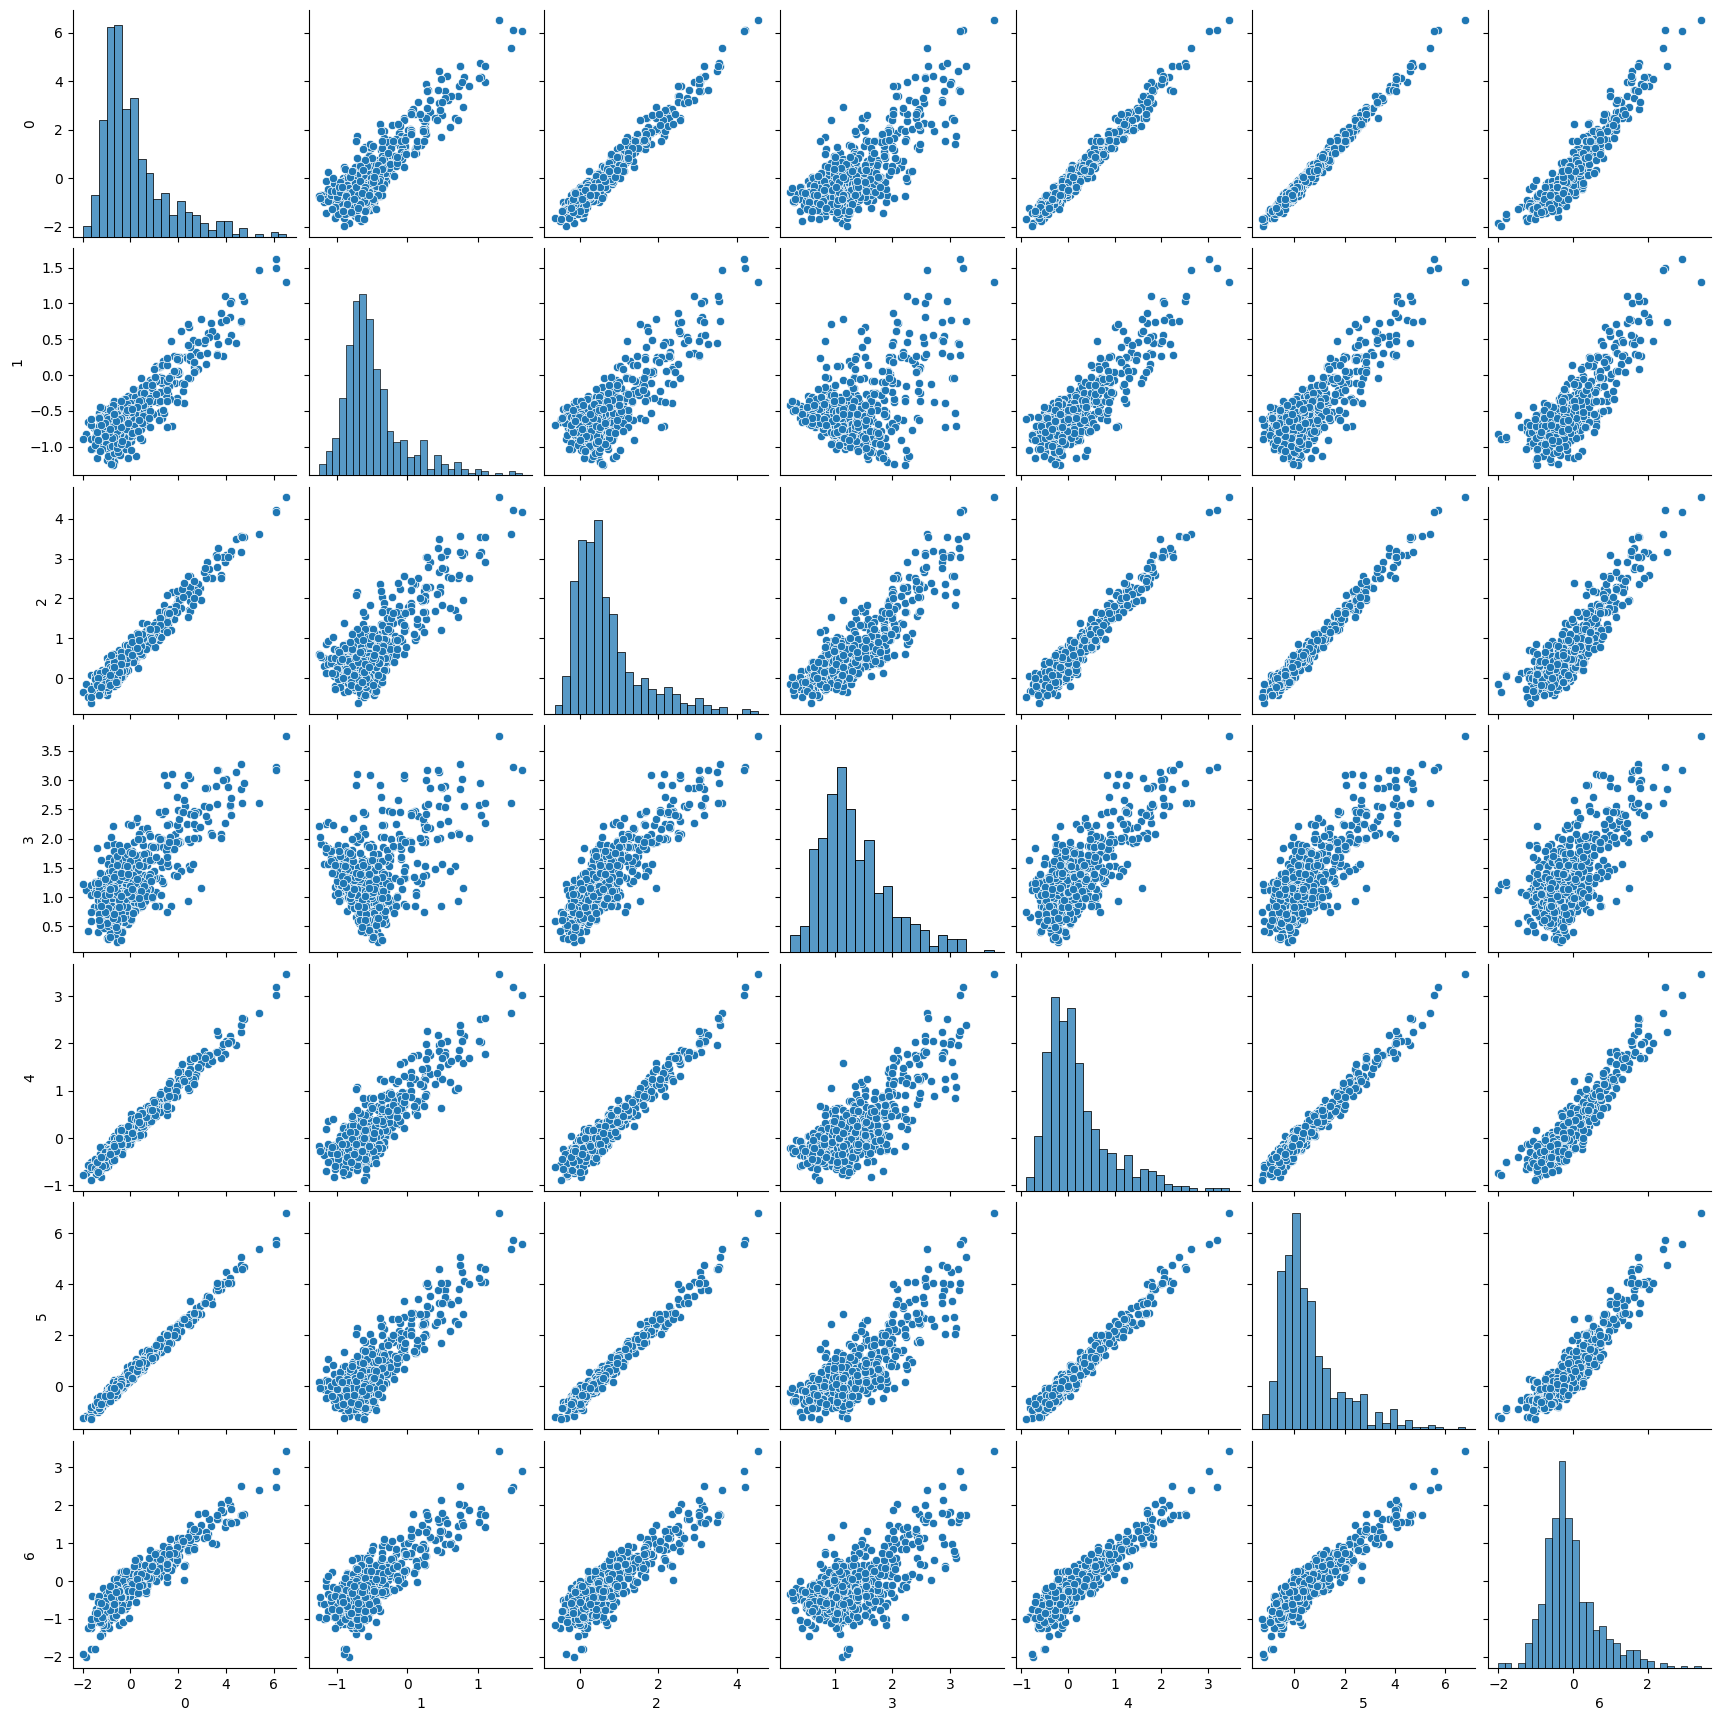

In [ ]:
sns.pairplot(generated_samples)